In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x0000023B22E76D10>, default_metadata=(), model_kwargs={})

In [3]:
#Pydantic LLM Schema
from typing import List, TypedDict
from pydantic import BaseModel, Field

class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="List of tasks to be performed by the worker.")

llm_with_schema = llm.with_structured_output(llm_schema)

# llm_with_schema.invoke("What is capital of France and what is population of France? ")

In [4]:
#Graph Schema
class graph_schema(TypedDict):
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

In [5]:
#Orchestrator Node
def orchestrator_node(state: graph_schema) -> graph_schema:
    user_query = state['query']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into smaller tasks for the worker to execute. "),
            ("user", "The user query is: {user_query}. Please generate one prompt per task for the worker to complete. ")

        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"user_query": user_query})

    state['tasks'] = response.tasks
    return state

In [6]:
#Execute Function
def execute(query:str):
    
    response = llm.invoke(f"Please execute the following task: {query}")
    return response.content


In [7]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state):
    tasks = state["tasks"]

    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        futures = executor.map(execute, tasks)

        for result in futures:
            results.append(result)

    state["results"] = results
    return state

In [8]:
#Collector Node
def collector_node(state: graph_schema) -> graph_schema:
    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker. "),
            ("user", "The worker has completed the following tasks: {results}. Please summarize the results in a concise manner. ")

        ]
    )

    chain = prompt | llm
    summary = chain.invoke({"results": results})

    state['summary'] = summary
    return state

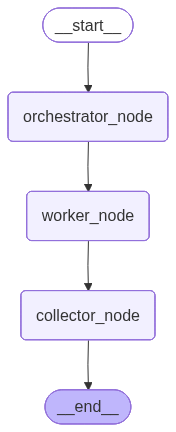

In [9]:
#Creating Graph and Executing
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

#Step 4 Compile the graph
from IPython.display import Image, display

Image(complex_graph.get_graph().draw_mermaid_png())

In [10]:
complex_graph.invoke(
    {
        "query": "What is capital of France and what is population of France? & What is the capital of Germany and what is the population of Germany? Compare the population of both countries. ",
        "tasks": [],
        "results": [],
        "summary": ""
    }
)

{'tasks': ['Identify the capital of France.',
  'Find the current population of France.',
  'Identify the capital of Germany.',
  'Find the current population of Germany.',
  'Compare the population of France and Germany and state the difference.'],
 'query': 'What is capital of France and what is population of France? & What is the capital of Germany and what is the population of Germany? Compare the population of both countries. ',
 'results': [[{'type': 'text',
    'text': 'The capital of France is **Paris**.',
    'extras': {'signature': 'Et4BCtsBAb4+9vti89Xg3lyP3VRnd3DLkF2LAB6iWSO7YGiQMXd11+d3zvYpdu+lt55QIeuGklZ5pHabKP6+ZISHG6RbbU5De/tqjRpCx6MbdX7unoROqfg/p/zLQ4V8GAaf2Z5NhUtPeApS4tX5ojB6MTSgx7HqEFAAo3NsgkRhOp9i1dIQJI5ZlvQLexnaWlcBIvq0TZBHgg1pyyGSqI2mwWntzrjzhxR6XH9RvW04w6hap0QbhMpfytIVAewV0MkuMHJRe0Bnf55KYB/ipdKQPLBV2rBMPOt1OOqJNJuF'}}],
  [{'type': 'text',
    'text': 'As of the latest official estimate from **INSEE** (the French National Institute of Statistics and Economic Stud

In [11]:
for chunk in complex_graph.stream(
    {
        "query": "What is capital of France and what is population of France? & What is the capital of Germany and what is the population of Germany? Compare the population of both countries. ",
        "tasks": [],
        "results": [],
        "summary": ""
    },
    stream_mode="updates"
):
    print(chunk)

{'orchestrator_node': {'tasks': ['Identify the capital city of France.', 'Determine the current population of France.', 'Identify the capital city of Germany.', 'Determine the current population of Germany.', 'Compare the populations of France and Germany and identify which country has a larger population.'], 'query': 'What is capital of France and what is population of France? & What is the capital of Germany and what is the population of Germany? Compare the population of both countries. ', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['Identify the capital city of France.', 'Determine the current population of France.', 'Identify the capital city of Germany.', 'Determine the current population of Germany.', 'Compare the populations of France and Germany and identify which country has a larger population.'], 'query': 'What is capital of France and what is population of France? & What is the capital of Germany and what is the population of Germany? Compare the population o